In [3]:
import numpy as np
from scipy import optimize
from scipy.constants import mu_0, epsilon_0
from scipy import fftpack
from scipy import sparse
from scipy.special import factorial
from scipy.signal import butter, filtfilt
from scipy.interpolate import interp1d, CubicSpline,splrep, BSpline
from scipy.sparse import csr_matrix, csc_matrix
import csv
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import display, Latex, Markdown
from scipy.linalg import lu_factor, lu_solve
from scipy import signal
import ipywidgets
import empymod
import discretize
import  os
import json
import pandas as pd

In [4]:
import torch
import torch.nn.functional as F
from torch.autograd.functional import jacobian
eps = torch.finfo(torch.float32).eps
print(eps)

1.1920928955078125e-07


In [11]:
from masa_utils import PsuedoLog
from masa_utils import DDR_f as DDR_f_np
from masa_utils import Pelton_res_f as Pelton_np
from masa_utils import InducedPolarizationSimulation as IPsim_np
from masa_utils import Optimization as Opt_np
from masa_utils_pytorch import InducedPolarizationSimulation
from masa_utils_pytorch import Pelton, DDR_f, DDC_f, DDP_r_f
from masa_utils_pytorch import Optimization, TorchHelper
 

In [115]:
res0= 1.0
# res_ref = 0.3
taus_log= np.r_[-3.0, -2.0, -1.0] #0.001
# taus_log= np.r_[-5.0, -1.0] #0.001
taus = 10**taus_log
ntau = len(taus)
# eta = 0.2
# etas = np.ones(ntau)*eta
etas= np.r_[0.2, 0.4,0.2]

parm_true = TorchHelper.to_tensor_r(np.r_[np.log(res0), etas])


$\rho_0 = 1.0$ \
$\eta_1= 0.2,\quad \eta_2 = 0.4, \quad \eta_3 = 0.2$ \
$\tau_1 = 1.0 \times 10^{-3}, \tau_2 = 1.0 \times 10^{-2}, \tau_3 = 1.0 \times 10^{-1}$

In [103]:
freq_start_log = -1
freq_end_log = 5
freq_step_log = 0.1
freq = np.logspace(freq_start_log, freq_end_log, int((freq_end_log - freq_start_log) / freq_step_log) + 1)
taus_axis_min = 1/2/np.pi/freq.max()
taus_axis_max = 1/2/np.pi/freq.min()

In [104]:
IP_model = DDR_f(freq=freq, taus=taus)
sim_obs = InducedPolarizationSimulation(ip_model=IP_model, mode="sip")
dobs = sim_obs.dpred(parm_true).detach()

In [105]:
def plot_sip(freq, dpreds, ax=None, **kwargs):
    if ax is None: 
        fig, ax = plt.subplots(2, 1, figsize=(5,3))
    nfreq = len(freq)

    default_kwargs = {
        "linestyle": "-",
        "color": "C0",
        "linewidth": 1.0,
        "marker": None,
        "markersize": 1,
    }
    default_kwargs.update(kwargs)
    nfreq = len(dpreds)//2

    sip_real = dpreds[:nfreq]
    sip_imag = dpreds[nfreq:]
    sip_abs = np.abs(sip_real + 1j * sip_imag)
    sip_phs = np.angle(sip_real + 1j * sip_imag, deg=True)
    ax[0].semilogx(freq, sip_abs, **default_kwargs)
    ax[1].semilogx(freq, sip_phs, **default_kwargs)

    ax[0].set_ylim(bottom=0)
    ax[0].set_ylabel(r'$|\rho^{\ast}|~(\Omega\cdot\mathrm{m})$')

    ax[1].set_ylabel(r'$\phi~(^\circ)~(\mathrm{deg}) $')

    for a in ax:
        a.set_xlabel("Frequency [Hz]")

    return ax

In [109]:
def plot_taus(freq, taus, ax=None, **kwargs):
    if ax is None: 
        fig, ax = plt.subplots(2, 1, figsize=(5,3))
    default_kwargs = {
        "linestyle": "-",
        "color": "C0",
        "linewidth": 1.0,
        "marker": None,
        "markersize": 1,
    }
    default_kwargs.update(kwargs)
    ntau = len(taus)
    for i in range(ntau):
        freq_tau = 1/2.0/np.pi/taus[i]
        label = f"$\\frac{{1}}{{2\\pi \\tau_{{{i+1}}}}}$"
        color = f"C{i+1}"
        ax[0].axvline(freq_tau, label=label, color=color, linestyle='--')
        ax[1].axvline(freq_tau, label=label, color=color, linestyle='--')
    return ax


In [110]:
def plot_etas(etas,taus, ax=None, **kwargs):
    if ax is None: 
        fig, ax = plt.subplots(1, 1, figsize=(5,3))
    ax.semilogx(taus, etas, **kwargs)
    ntau = len(etas)
    for i in range(ntau):
        color = f"C{i+1}"
        ax.semilogx(taus[i], etas[i], color=color, **kwargs)
    ax.set_xlabel(r"$\tau_k$ [s]")
    ax.set_ylabel(r"$\eta_k$")
    return ax

C:\Users\81805\AppData\Local\Temp\ipykernel_24600\1494639437.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  a.legend()


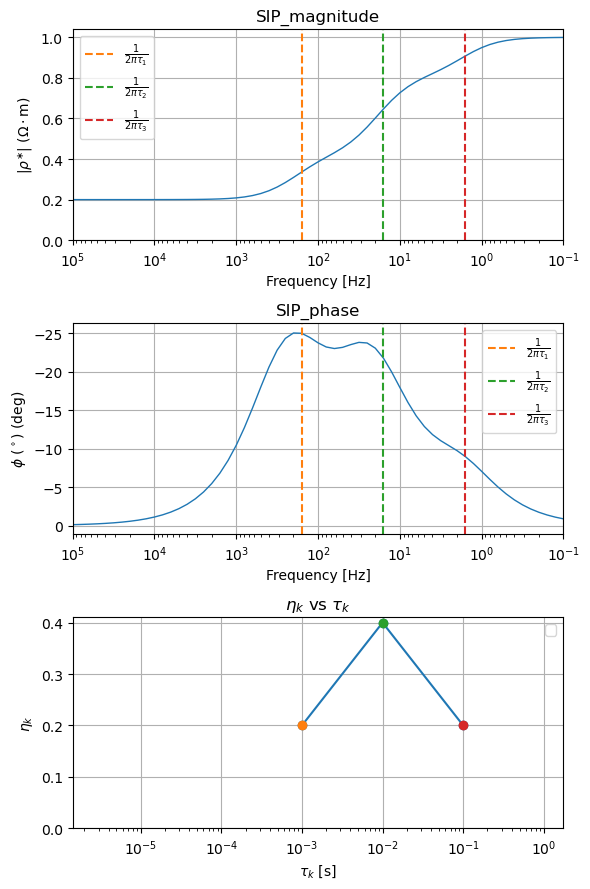

In [114]:
fig, ax = plt.subplots(3, 1, figsize=(6,9))

ax_sip = [ax[0], ax[1]]
ax_etas = ax[2]
ax_sip = plot_sip(freq, dobs.numpy(), ax=ax_sip)
ax_sip = plot_taus(freq, taus, ax=ax_sip)
etas = parm_true[1:]
ax_etas = plot_etas(taus=taus, etas=etas, ax=ax_etas,
                    linestyle='-', marker='o')

ax_sip[1].invert_yaxis()
ax_etas.set_xlim(left=taus_axis_min*0.9, right=taus_axis_max*1.1)
ax_etas.set_ylim(bottom=0)
for a in ax_sip:
    a.set_xlim(left=1e5, right=1e-1) 
ax_sip[0].set_title('SIP magnitude')
ax_sip[1].set_title('SIP phase')

ax_sip[0].set_title(f"SIP_magnitude")
ax_sip[1].set_title(f"SIP_phase")
ax_etas.set_title(fr"$\eta_k$ vs $\tau_k$")

for a in ax:
    a.grid()
    a.legend()

plt.tight_layout()